In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)

X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)
print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Dataset Shape: (20640, 8)

Features:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [3]:
print("Dataset Information:")
print(X.info())

print("\nMissing Values:")
print(X.isnull().sum())

print("\nStatistical Summary:")
display(X.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
X_engineered = X.copy()

X_engineered["RoomsPerHousehold"] = X_engineered["AveRooms"] / X_engineered["AveOccup"]
X_engineered["BedroomsPerRoom"] = X_engineered["AveBedrms"] / X_engineered["AveRooms"]
X_engineered["PopulationPerHousehold"] = X_engineered["Population"] / X_engineered["AveOccup"]

X_engineered.replace([np.inf, -np.inf], np.nan, inplace=True)
X_engineered.fillna(0, inplace=True)

print(X_engineered.head())
print("New Shape:", X_engineered.shape)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  RoomsPerHousehold  BedroomsPerRoom  PopulationPerHousehold  
0    -122.23           2.732919         0.146591                   126.0  
1    -122.22           2.956685         0.155797                  1138.0  
2    -122.24           2.957661         0.129516                   177.0  
3    -122.25           2.283154         0.184458                   219.0  
4    -122.25           2.879646         0.172096                   259.0  
New Shape: (20640, 11)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 11)
Testing data: (4128, 11)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression
RMSE: 0.6738172773395144
R² Score: 0.6535205948827304


In [8]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression
RMSE: 0.6738201776284443
R² Score: 0.6535176121971285


In [9]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regressor")
print("RMSE:", tree_rmse)
print("R² Score:", tree_r2)

Decision Tree Regressor
RMSE: 0.6423226429452761
R² Score: 0.6851529678970514


In [10]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        tree_rmse
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        tree_r2
    ]
})

display(results)

,Model,RMSE,R2 Score
0,Linear Regression,0.673817,0.653521
1,Ridge Regression,0.673820,0.653518
2,Decision Tree,0.642323,0.685153


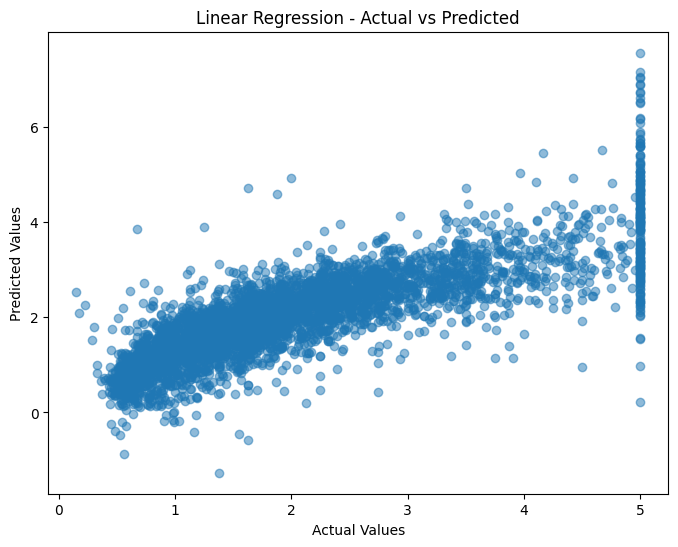

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

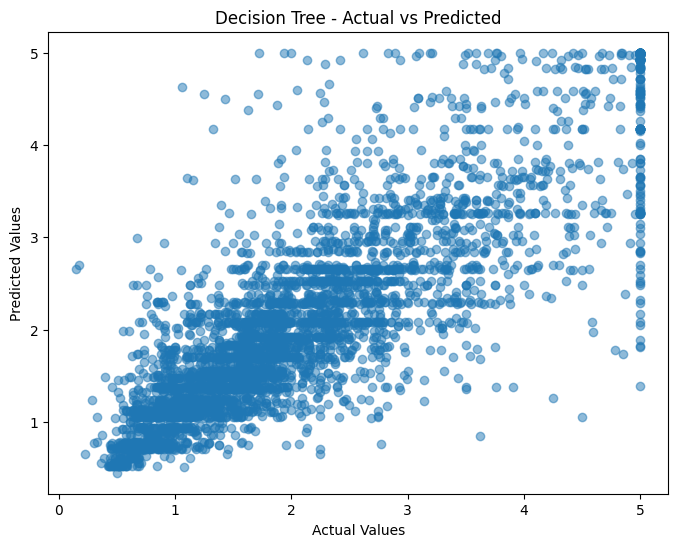

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, tree_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree - Actual vs Predicted")

plt.show()

In [13]:
results.to_csv("model_comparison.csv", index=False)

print("Results saved successfully.")

Results saved successfully.
